# Publication-quality figures -- two-stage switching model

Parameters below are `auto_fit_parameters_mle.py`'s automated fit against
the real grouped lifespan data: DMSO baseline `(a0, log_g0, sigma)` and
Auxin_day_10's own independent `(a0_auxin10, log_g0_auxin10)`, each fit by
maximizing `_weighted_neg_log_lik`, a Monte Carlo grouped-data
log-likelihood (each observed death contributes the simulated model's own
interval probability mass, each censored worm its survival probability --
see that notebook's own markdown for the full derivation), as an
alternative to a weighted least-squares fit against the empirical KM
curve's values (`_weighted_log_loss`, also defined there). Drives this
project's figures: a conceptual potential/dynamical-regimes schematic
(Figure 1), representative trajectories (Figure 2), and simulated vs. real
survival curves with a goodness-of-fit table (Figure 3). Fit under
`Z_M_RANGE=(4,10)`, `Z_H_RANGE=(40,60)` -- both barriers and `sigma`
constrained to that biologically-plausible region as a **hard constraint**
(see `auto_fit_parameters_mle.py` Step 0/1/1b), not just a loose sanity box.

**Known, accepted limitation** (see that notebook's `R`-vs-CV sweep): the
fit's death-time variability (simulated CV ~0.35) is still wider than the
real `DMSO_day_10` cohort's (CV ~0.176) -- closing that gap would need `R`
(and `Z_H_RANGE`'s ceiling) pushed well past the `Z_AUXIN_CAP=80`
biologically-motivated limit used throughout this project. Given the
underlying data's own resolution (digitized/grouped survival curves, not
dense individual-worm time series), that additional precision isn't
expected to be resolvable with this data -- accepted as a known model
limitation rather than chased further.

**Three conditions, two dynamical regimes:**
- **DMSO_day_10** (single phase): simulated from day 0 under the DMSO
  baseline `(a0, g0)` throughout.
- **Auxin_day_10** (single phase, own parameters): worms received auxin
  from day 0, so are simulated from day 0 under their own independently
  fitted `(a0_auxin10, g0_auxin10)` throughout -- never on DMSO dynamics at
  any observed age, so there is no baseline phase to switch out of.
- **Auxin_day_21** (two-stage switch): worms follow the DMSO baseline
  `(a0, g0)` up to day 21, then switch to Auxin_day_10's own fitted
  `(a0_auxin10, g0_auxin10)` for the remainder -- i.e. post-switch dynamics
  are exactly Auxin_day_10's fitted dynamics, on the reasoning that worms
  switched onto auxin at day 21 should settle into the same post-auxin
  dynamics as worms that received auxin from day 0.

Reuses the shared simulation utilities already in `src/` rather than
reimplementing them: `model.simulate_fpt_and_state` / `model.km_from_fpt`,
and `model.simulate_two_phase` / `model.simulate_two_phase_trajectories`
for the day-21 intervention switch. Those take the `(alpha, Z)`
parameterization, with `Z = alpha / g` -- exactly `z_h` below -- so they
drop in directly for the `(a, g)` two-stage FPT/trajectory helpers this
figure set was originally sketched against.

In [55]:
import csv
import sys
import warnings
from pathlib import Path

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.lines import Line2D

warnings.filterwarnings("ignore")

NOTEBOOK_DIR = Path(__file__).resolve().parent if "__file__" in globals() else Path.cwd()
SRC_DIR = NOTEBOOK_DIR.parent / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

FIGURES_DIR = NOTEBOOK_DIR / "figures"
FIGURES_DIR.mkdir(exist_ok=True)

TABLES_DIR = NOTEBOOK_DIR / "tables"
TABLES_DIR.mkdir(exist_ok=True)

from model import (
    km_from_fpt,
    simulate_fpt_and_state,
    simulate_two_phase,
    simulate_two_phase_trajectories,
)
from metrics import goodness_of_fit
from data import kaplan_meier_curve, load_raw_survival_data

## Publication rcParams

In [56]:
matplotlib.rcParams.update({
    'font.family':      'sans-serif',
    'font.sans-serif':  ['Helvetica', 'Arial', 'DejaVu Sans'],
    'font.size':         9,
    'axes.titlesize':    9,
    'axes.labelsize':    9,
    'xtick.labelsize':   8,
    'ytick.labelsize':   8,
    'legend.fontsize':   8,
    'axes.linewidth':    0.8,
    'xtick.major.width': 0.8,
    'ytick.major.width': 0.8,
    'lines.linewidth':   1.5,
    'figure.dpi':        150,
    'savefig.dpi':       300,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'legend.frameon':    False,
    'axes.grid':         False,
})
cm = 1 / 2.54  # one centimetre in inches

## Fixed parameters

In [57]:
# DMSO baseline and sigma -- fitted by auto_fit_parameters_mle.py Step 1
# (fit_single_phase, MLE objective _weighted_neg_log_lik), constrained to
# Z_M_RANGE=(4,10), Z_H_RANGE=(40,60), GAMMA_MIN=50.
a0, log_g0, sigma = 0.1553, -2.5439, 1.5941
sigma_sq = sigma ** 2  # model.py's simulation functions take the noise VARIANCE

# Auxin_day_10's own independent single-phase parameters -- auto_fit_parameters_mle.py
# Step 1b (fit_single_phase, sigma fixed at the DMSO fit above). Used both
# for the Auxin_day_10 condition itself and as Auxin_day_21's post-switch
# (phase 2) dynamics -- see markdown above.
a0_auxin10, log_g0_auxin10 = 0.1035, -2.7358

g0 = 10.0 ** log_g0
g0_auxin10 = 10.0 ** log_g0_auxin10

# Phase 2 (post day-21-switch) dynamics = Auxin_day_10's own fitted params.
a1, g1 = a0_auxin10, g0_auxin10

# z_m (drift-to-exponential crossover) = sqrt(sigma_sq / a), NOT sigma / a --
# see auto_fit_parameters_mle.py's Step 0 derivation (Podolskiy et al.
# arXiv:1502.04307, Appendix B, crossover statement following Eq. B19/B20).
z_m0, z_h0 = sigma / np.sqrt(a0), a0 / g0
z_m1, z_h1 = sigma / np.sqrt(a1), a1 / g1
z_m0_auxin10, z_h0_auxin10 = sigma / np.sqrt(a0_auxin10), a0_auxin10 / g0_auxin10
R0, R1 = z_h0 / z_m0, z_h1 / z_m1

tI_10, tI_21 = 10.0, 21.0
T_MAX = 60.0
DT = 0.1  # matches the dt used to fit these parameters in
          # 0_auto_fit_parameters_mle.py, so the published figures show the
          # same simulation the fit was actually scored against
N_KM = 20000  # particles for KM estimation -- kept large so the simulated
              # KM curves read as smooth continuous lines rather than a
              # visibly stepped/jagged staircase (Figure 3)
N_TR = 40    # trajectories to display

# Wong (2011) colorblind-safe palette
C_WT, C_A10, C_A21 = '#0072B2', '#009E73', '#D55E00'

print("Derived parameters:")
print(f"  g0={g0:.4e}   g1={g1:.4e}   g0_auxin10={g0_auxin10:.4e}")
print(f"  a0={a0}       a1={a1:.4f}       a0_auxin10={a0_auxin10:.4f}")
print(f"  z_m0={z_m0:.3f}  z_h0={z_h0:.2f}  R0={R0:.2f}")
print(f"  z_m1={z_m1:.3f}  z_h1={z_h1:.2f}  R1={R1:.2f}")
print(f"  z_m0_auxin10={z_m0_auxin10:.3f}  z_h0_auxin10={z_h0_auxin10:.2f}")

Derived parameters:
  g0=2.8582e-03   g1=1.8374e-03   g0_auxin10=1.8374e-03
  a0=0.1553       a1=0.1035       a0_auxin10=0.1035
  z_m0=4.045  z_h0=54.33  R0=13.43
  z_m1=4.955  z_h1=56.33  R1=11.37
  z_m0_auxin10=4.955  z_h0_auxin10=56.33


## Figure 1 -- Potential and dynamical regimes schematic

A conceptual companion to Figure 2, not tied to the fitted parameters
above: illustrates the cubic potential `V(z) = -(alpha/2)z^2 - (g/3)z^3`
underlying the `dz/dt = alpha*z + g*z^2` drift used throughout this
project, and the three qualitatively distinct dynamical regimes a
trajectory passes through as `z` rises from `0` toward the unstable fixed
point `-alpha/g` (Podolskiy et al. arXiv:1502.04307): diffusion-dominated,
exponential growth, then hyperbolic blow-up approaching the barrier.

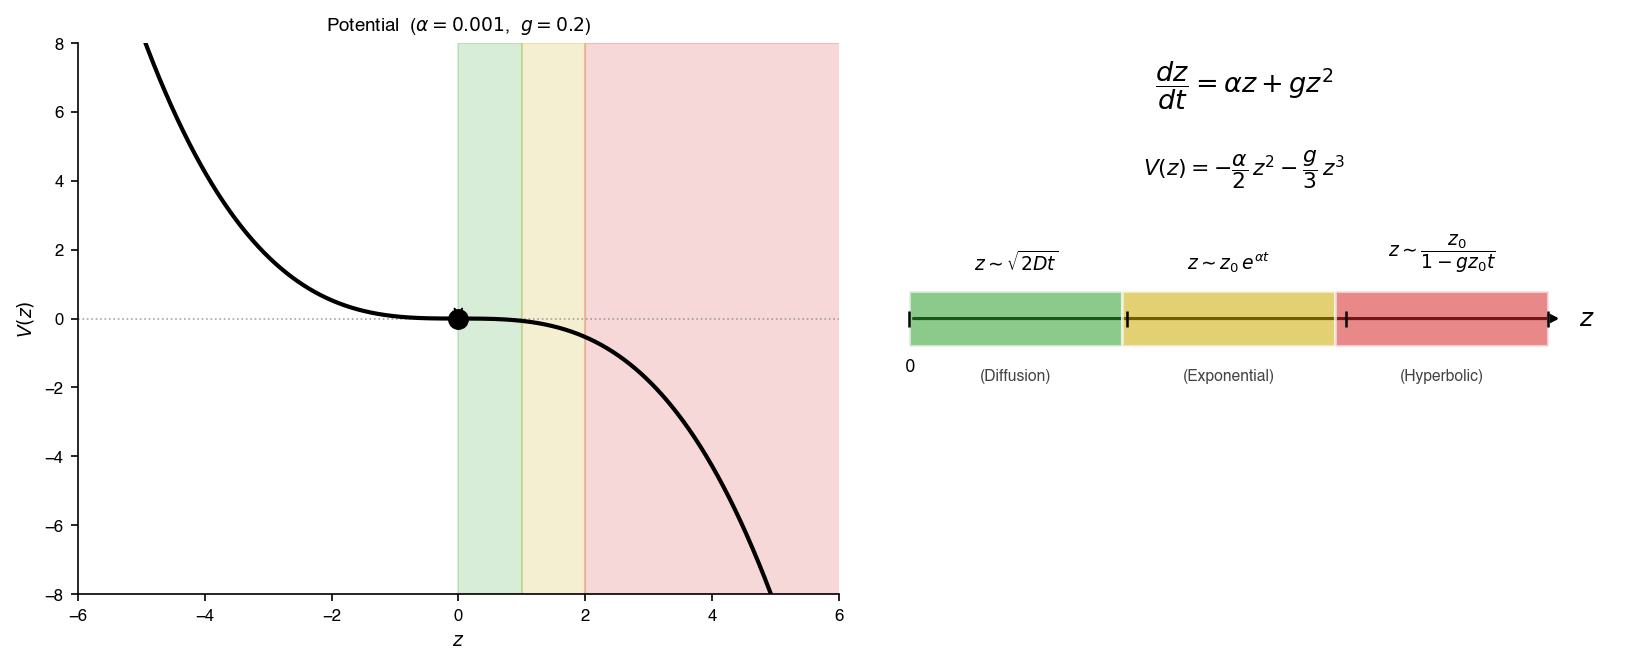

In [58]:
import matplotlib.patches as mpatches

# Local, illustrative (alpha, g) -- not this notebook's fitted DMSO/Auxin
# values. alpha=0 is the genuinely unstable/marginal case this figure
# illustrates: z=0 has zero curvature (V''(0) = -alpha = 0), so there's no
# barrier to cross -- any positive fluctuation falls directly under the
# g*z^2 nonlinearity alone, straight into the exponential/hyperbolic
# regimes to its right.
a_schem = 0.001
g_schem = 0.2
z_unstable = -a_schem / g_schem  # = 0 here: no separate fixed point to the
                                  # right of z=0 when alpha=0


def potential(z, a, g):
    return -0.5 * a * z**2 - (g / 3) * z**3


z_arr = np.linspace(-6, 6, 2000)
V = potential(z_arr, a_schem, g_schem)
V_barrier = potential(z_unstable, a_schem, g_schem)

# Regime colours
C_DIFF = '#2ca02c'  # green
C_EXP = '#ccaa00'  # yellow/goldenrod
C_HYP = '#d62728'  # red

fig1, (ax1_l, ax1_r) = plt.subplots(1, 2, figsize=(11, 4.5))

# ── Left panel: potential with coloured regime boxes ──
for (lo, hi, col) in [(0, 1, C_DIFF), (1, 2, C_EXP), (2, 8, C_HYP)]:
    ax1_l.axvspan(lo, hi, alpha=0.18, color=col, zorder=0)

ax1_l.plot(z_arr, V, 'k-', lw=2, zorder=3)

# Horizontal dotted line at barrier energy
ax1_l.axhline(V_barrier, color='gray', lw=0.8, ls=':', alpha=0.7, zorder=2)

# Ball at stable point z = 0
ax1_l.plot(0, 0, 'o', color='black', markersize=9, zorder=5)

# Arrow from ball up to barrier energy level
ax1_l.annotate("", xy=(0, V_barrier), xytext=(0, 0),
               arrowprops=dict(arrowstyle="->", color='black', lw=1.0,
                               shrinkA=6, shrinkB=2), zorder=4)

ax1_l.set_xlabel('$z$')
ax1_l.set_ylabel('$V(z)$')
ax1_l.set_title(rf'Potential  ($\alpha = {a_schem}$,  $g = {g_schem}$)')
ax1_l.set_xlim(-6, 6)
ax1_l.set_ylim(-8, 8)

# ── Right panel: schematic z-axis with regime boxes + equations ──
ax1_r.set_xlim(0, 1)
ax1_r.set_ylim(0, 1)
ax1_r.axis('off')

ax1_r.text(0.5, 0.97, r'$\dfrac{dz}{dt} = \alpha z + gz^2$',
           ha='center', va='top', fontsize=13, transform=ax1_r.transAxes)
ax1_r.text(0.5, 0.81, r'$V(z) = -\dfrac{\alpha}{2}\,z^2 - \dfrac{g}{3}\,z^3$',
           ha='center', va='top', fontsize=10.5, transform=ax1_r.transAxes)

# z-axis arrow
y_ax = 0.50
x_lo = 0.06
x_hi = 0.92
ax1_r.annotate("", xy=(x_hi, y_ax), xytext=(x_lo, y_ax),
               xycoords='axes fraction', textcoords='axes fraction',
               arrowprops=dict(arrowstyle="-|>", lw=1.5, color='black'))
ax1_r.text(x_hi + 0.02, y_ax, '$z$', ha='left', va='center',
           fontsize=12, transform=ax1_r.transAxes)

# Tick marks at regime boundaries
for xf in [x_lo, x_lo + (x_hi - x_lo) / 3, x_lo + 2 * (x_hi - x_lo) / 3, x_hi - 0.02]:
    ax1_r.plot(xf, y_ax, '|', color='black', markersize=8, markeredgewidth=1.2,
               transform=ax1_r.transAxes, zorder=4, clip_on=False)

ax1_r.text(x_lo, y_ax - 0.07, '$0$', ha='center', va='top',
           fontsize=8, transform=ax1_r.transAxes)

# Three coloured regime boxes
box_x0 = x_lo
box_w = x_hi - x_lo - 0.02  # same span as z-axis
box_h = 0.10
box_y = y_ax - box_h / 2

regimes = [
    (C_DIFF, r'$z \sim \sqrt{2Dt}$', 'Diffusion'),
    (C_EXP, r'$z \sim z_0\,e^{\alpha t}$', 'Exponential'),
    (C_HYP, r'$z \sim \dfrac{z_0}{1-gz_0t}$', 'Hyperbolic'),
]

for i, (col, eq, name) in enumerate(regimes):
    bx = box_x0 + i * box_w / 3
    bw = box_w / 3
    ax1_r.add_patch(mpatches.FancyBboxPatch(
        (bx, box_y), bw, box_h,
        boxstyle="square,pad=0",
        facecolor=col, alpha=0.55,
        edgecolor='white', lw=1.5,
        transform=ax1_r.transAxes, zorder=3))
    # Label above box
    ax1_r.text(bx + bw / 2, box_y + box_h + 0.03, eq,
               ha='center', va='bottom', fontsize=9,
               transform=ax1_r.transAxes)
    # Name below box
    ax1_r.text(bx + bw / 2, box_y - 0.04, f'({name})',
               ha='center', va='top', fontsize=7.5, color='#444444',
               transform=ax1_r.transAxes)

fig1.tight_layout()
fig1.savefig(FIGURES_DIR / 'pub_fig1_potential_unstable_auxin10switch.png', bbox_inches='tight', dpi=600)
plt.show()

**Figure 1 legend (draft).** **Instability dynamics of *C.~elegans*.**
*Left*: Potential $V(z)$ for the unstable case $\alpha > 0$, in which the
linear instability rate $\alpha$ drives exponential divergence away from
$z=0$. Coloured bands delineate the three dynamical regimes a trajectory
passes through as $z$ rises from $0$ toward the failure threshold:
diffusion (green, $z \sim \sqrt{2Dt}$), where noise $D$ dominates near the
origin; exponential (yellow, $z \sim z_0\,e^{\alpha t}$), where the linear
drift term drives growth; and hyperbolic (red,
$z \sim z_0/(1-g z_0 t)$), where the nonlinear $gz^2$ term drives
finite-time blow-up toward the failure threshold $Z = \alpha/g$. *Right*:
Schematic summary of the same three regimes along the $z$-axis, together
with the governing Langevin equation and potential.

## Helpers specific to this figure set

`simulate_two_phase`/`simulate_two_phase_trajectories` already implement
the two-stage FPT/trajectory simulation (see `src/model.py`); the
function below only handles a presentation concern that doesn't
belong in `src/`: reading each trajectory's own death time back out of the
`z_paths` array returned by `simulate_two_phase_trajectories` (which
records state, not death time, since it's meant for plotting).

In [59]:
def _death_times_from_trajectories(t_grid, z_paths):
    """First NaN time per column of z_paths, or NaN if that column survived."""
    is_nan = np.isnan(z_paths)
    has_died = is_nan.any(axis=0)
    first_nan_idx = np.argmax(is_nan, axis=0)
    return np.where(has_died, t_grid[first_nan_idx], np.nan)

## Run simulations

In [60]:
T_wt, _, _ = simulate_fpt_and_state(
    N_KM, a0, g0, sigma_sq, z_h0,
    z0=0.0, dt=DT, t_max=T_MAX, rng=np.random.default_rng(42))

# Auxin_day_10: own single-phase population from day 0 (own a0_auxin10,
# g0_auxin10), not a switch out of DMSO dynamics -- see markdown above.
T_a10, _, _ = simulate_fpt_and_state(
    N_KM, a0_auxin10, g0_auxin10, sigma_sq, z_h0_auxin10,
    z0=0.0, dt=DT, t_max=T_MAX, rng=np.random.default_rng(42))

T_a21 = simulate_two_phase(
    N_KM, a0, z_h0, a1, z_h1, sigma_sq, tI_21, T_MAX, DT)

## KM curves

In [61]:
t_eval = np.linspace(0, T_MAX, 600)
S_wt = km_from_fpt(T_wt, t_eval, t_max=T_MAX)
S_a10 = km_from_fpt(T_a10, t_eval, t_max=T_MAX)
S_a21 = km_from_fpt(T_a21, t_eval, t_max=T_MAX)

## Trajectories (Auxin-d21 two-stage)

In [62]:
t_traj, z_traj = simulate_two_phase_trajectories(
    N_TR, a0, z_h0, a1, z_h1, sigma_sq, tI_21, T_MAX, DT,
    rng=np.random.default_rng(0))
t_death_traj = _death_times_from_trajectories(t_traj, z_traj)

# Classify each trajectory by fate
died_s1 = (~np.isnan(t_death_traj)) & (t_death_traj <= tI_21)
died_s2 = (~np.isnan(t_death_traj)) & (t_death_traj > tI_21)
survived = np.isnan(t_death_traj)

print(f"\nTrajectory fates (N={N_TR}):  "
      f"died stage 1 = {died_s1.sum()},  "
      f"died stage 2 = {died_s2.sum()},  "
      f"survived = {survived.sum()}")


Trajectory fates (N=40):  died stage 1 = 27,  died stage 2 = 13,  survived = 0


## Figure 2 -- Representative trajectories with boxed zoom insets (day 10 vs day 21)

N idx_show: 40
stage1 deaths: 27
stage2 deaths: 13
survivors   : 0


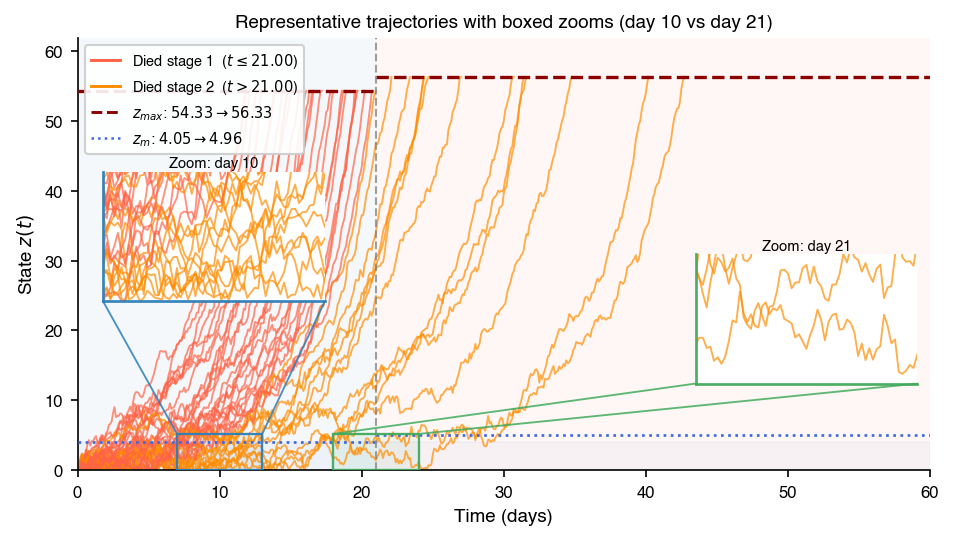

In [63]:
from matplotlib.patches import ConnectionPatch, Rectangle

# --- parameters ---
N_SHOW = min(N_TR, 50)
Z_MEM = min(z_m0, z_m1)
Z_TOP = z_h1 * 1.10

C_SURV = 'steelblue'
C_D1 = 'tomato'
C_D2 = 'darkorange'

# Zoom settings (same window width and same y-range across all insets)
ZOOM_DAYS = [10.0, 21.0]
W_Z = 3.0                     # half-width in days (=> total span 6 days)
y0, y1 = 0.0, 1.28 * Z_MEM    # fixed y-limits for comparability

# ROI colors (match inset frame + ROI rectangle + connectors)
ROI_COLORS = ['#2c7fb8', '#41ab5d']  # blue, green

# Inset placement in axes fraction coords [x0, y0, w, h]
INSET_POS = [
    [0.03, 0.39, 0.26, 0.30],   # day 10 (top-left)
    [0.725, 0.2, 0.26, 0.30],   # day 21 (top-right)
]

idx_show = list(range(N_TR))[:N_SHOW]
print("N idx_show:", len(idx_show))
print("stage1 deaths:", int(np.sum(died_s1[idx_show])))
print("stage2 deaths:", int(np.sum(died_s2[idx_show])))
print("survivors   :", int(len(idx_show) - np.sum(died_s1[idx_show]) - np.sum(died_s2[idx_show])))


def traj_style(k):
    """Return (color, alpha) by fate."""
    if died_s1[k]:
        return C_D1, 0.70
    if died_s2[k]:
        return C_D2, 0.70
    return C_SURV, 0.55


def add_roi(ax, x0, x1, y0, y1, color, lw=1.2, alpha=0.10):
    """Shaded ROI rectangle on main plot."""
    rect = Rectangle((x0, y0), x1 - x0, y1 - y0,
                      facecolor=color, edgecolor=color,
                      linewidth=lw, alpha=alpha, zorder=1)
    ax.add_patch(rect)
    # crisp border on top
    rect2 = Rectangle((x0, y0), x1 - x0, y1 - y0,
                       facecolor='none', edgecolor=color,
                       linewidth=lw, alpha=0.95, zorder=6)
    ax.add_patch(rect2)
    return rect2


# ── main figure ────────────────────────────────────────────────
fig2, ax2 = plt.subplots(figsize=(16 * cm, 9 * cm))
ax2.axvspan(0, tI_21, alpha=0.05, color='steelblue', lw=0, zorder=0)
ax2.axvspan(tI_21, T_MAX, alpha=0.05, color='tomato', lw=0, zorder=0)

# Main plot: trajectories
for k in idx_show:
    z_k = z_traj[:, k]
    mask = ~np.isnan(z_k)
    if mask.sum() < 2:
        continue
    col, alph = traj_style(k)
    ax2.plot(t_traj[mask], z_k[mask], color=col, lw=0.9, alpha=alph, zorder=2)

# reference lines/regions
ax2.hlines(z_m0, 0, tI_21, colors='royalblue', lw=1.3, ls=':', zorder=3)
ax2.hlines(z_m1, tI_21, T_MAX, colors='royalblue', lw=1.3, ls=':', zorder=3)
ax2.hlines(z_h0, 0, tI_21, colors='darkred', lw=1.6, ls='--', zorder=3)
ax2.hlines(z_h1, tI_21, T_MAX, colors='darkred', lw=1.6, ls='--', zorder=3)
ax2.axvline(tI_21, color='gray', lw=1.0, ls='--', alpha=0.75, zorder=4)
ax2.axhspan(0, Z_MEM, color='royalblue', alpha=0.04, zorder=0)

# Create insets and ROIs for each zoom day
for (Tz, color, pos) in zip(ZOOM_DAYS, ROI_COLORS, INSET_POS):
    x0, x1 = Tz - W_Z, Tz + W_Z

    # ROI on main axis
    add_roi(ax2, x0, x1, y0, y1, color=color, lw=1.1, alpha=0.08)

    # inset axis
    axins = ax2.inset_axes(pos)

    # plot trajectories in the inset
    for k in idx_show:
        z_k = z_traj[:, k]
        m = (t_traj >= x0) & (t_traj <= x1) & (~np.isnan(z_k))
        if m.sum() < 1:
            continue
        col, alph = traj_style(k)
        axins.plot(t_traj[m], z_k[m], color=col, lw=0.9, alpha=min(0.75, alph))

    # inset styling
    axins.set_xlim(x0, x1)
    axins.set_ylim(y0, y1)
    axins.set_xticks([])
    axins.set_yticks([])

    for sp in axins.spines.values():
        sp.set_edgecolor(color)
        sp.set_linewidth(1.3)
        sp.set_alpha(0.95)

    axins.set_title(f'Zoom: day {Tz:.0f}', fontsize=7, pad=2)

    # --- connectors: ROI top corners -> inset bottom corners ---
    p_main_L = (x0, y1)
    p_main_R = (x1, y1)
    p_ins_L = (x0, y0)
    p_ins_R = (x1, y0)

    conL = ConnectionPatch(
        xyA=p_ins_L, coordsA=axins.transData,
        xyB=p_main_L, coordsB=ax2.transData,
        color=color, lw=0.9, alpha=0.85, zorder=10)
    conR = ConnectionPatch(
        xyA=p_ins_R, coordsA=axins.transData,
        xyB=p_main_R, coordsB=ax2.transData,
        color=color, lw=0.9, alpha=0.85, zorder=10)
    fig2.add_artist(conL)
    fig2.add_artist(conR)

legend_handles = [
    Line2D([0], [0], color=C_D1, lw=1.4, label=rf'Died stage 1  ($t \leq {tI_21:.2f}$)'),
    Line2D([0], [0], color=C_D2, lw=1.4, label=rf'Died stage 2  ($t > {tI_21:.2f}$)'),
    Line2D([0], [0], color='darkred', lw=1.4, ls='--',
           label=rf'$z_{{max}}$: ${z_h0:.2f} \to {z_h1:.2f}$'),
    Line2D([0], [0], color='royalblue', lw=1.2, ls=':',
           label=rf'$z_m$: ${z_m0:.2f} \to {z_m1:.2f}$'),
]

ax2.legend(handles=legend_handles, fontsize=7, loc='upper left',
           frameon=True, framealpha=0.90)

ax2.set_xlabel('Time (days)')
ax2.set_ylabel('State $z(t)$')
ax2.set_title('Representative trajectories with boxed zooms (day 10 vs day 21)', pad=5)
ax2.set_xlim(0, T_MAX)
ax2.set_ylim(0, Z_TOP)

fig2.tight_layout(pad=0.55)
fig2.savefig(FIGURES_DIR / 'pub_fig2_trajectories_auxin10switch.png', bbox_inches='tight', dpi=600)
plt.show()

**Figure 2 legend (draft).** **Trajectories reveal the absence of
explicit time dependence.** Representative stochastic trajectories $z(t)$
from the Langevin model are shown for *C.~elegans* that die before
intervention (tomato) or die after intervention (dark orange). The
vertical dashed line marks the intervention time; dotted horizontal lines
indicate the drift-to-exponential level $z_m$, and dashed horizontal
lines denote the exponential-to-hyperbolic transition level $z_h$. Boxed
regions and corresponding insets compare dynamics at day 10 (early phase)
and day 21 (at intervention). Despite the difference in chronological
time, the local fluctuation structure and dispersion of trajectories
within the low-state regime are indistinguishable. This reflects the
Markov (i.e., memoryless) nature of the dynamics: future evolution
depends only on the current state $z(t)$, not on elapsed time. Late-life
individuals occupying the same region of state space are dynamically
equivalent to earlier ones, indicating that mortality risk is determined
by instantaneous state rather than explicit time dependence.

## Figure 3 -- Simulated vs. real survival curves, with goodness of fit

Simulated (solid) and real (dashed) curves for each condition share a
color and sit on the same axes, so the two overlap directly rather than
living in separate panels. The "real" curve here is each condition's own
Kaplan-Meier curve computed directly from the real grouped lifespan data
(`data/raw/*.csv`, via `data.py`) -- the **same data source and loading
as `auto_fit_parameters_mle.py`**, rather than an earlier hand-digitized
plot reconstruction. Goodness of fit (`metrics.goodness_of_fit`: RMSE and
Kolmogorov-Smirnov distance, the same two statistics used throughout
`auto_fit_parameters_mle.py`) is computed between each simulated curve and
its own real KM curve, evaluated at the real curve's own observed time
points, and reported in the summary table below the figure (kept out of
the figure itself/legend, for a cleaner submission-ready plot).

**Reviewer note -- the simulated curves' tails.** A smoothly-decaying
curve asymptoting toward zero looks visually identical to any other curve
doing the same, at linear scale, regardless of how different their true
(tiny) values actually are -- so all three conditions' simulated lines can
look like they "end" together (implying the same maximum lifespan for
every condition, including the control) even though they don't. Each
simulated curve below is truncated right where it first drops to/below
`SIM_FLOOR` (1% survival), with a marker at its own distinct stopping
point (its exact day/value reported in the summary table, not annotated
directly on the figure), rather than drawn on past the point where each
curve's remaining decay is no longer informative. 1% is a round,
easily-stated cutoff still well above the `N_KM=20000`-path simulation's
own resolution floor (`1/(N_KM+1)`), so the truncation point reflects a
real, biologically-legible survival level rather than simulation noise.

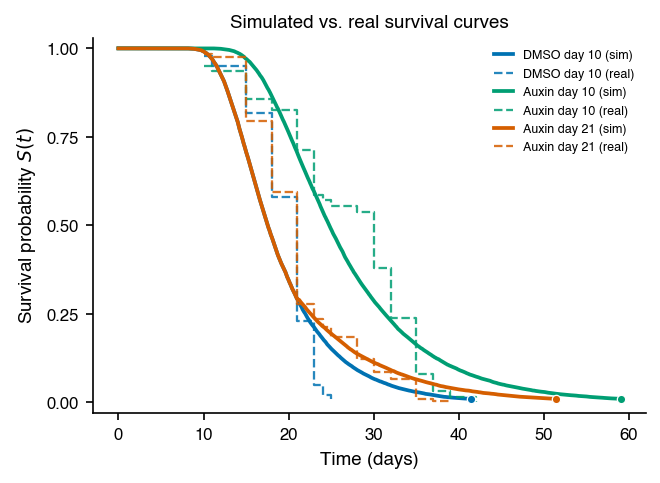

In [64]:
raw_data = load_raw_survival_data()


def make_curve_dict(name):
    """(t_emp, S_emp, t_max) for one condition, straight off its real
    grouped data -- same construction as auto_fit_parameters_mle.py's own
    make_curve_dict, so both notebooks score goodness of fit identically."""
    d = raw_data[name]
    kmf = kaplan_meier_curve(d)
    t_unique = np.unique(d.t)
    S_emp = kmf.survival_function_at_times(t_unique).to_numpy()
    return {"t_emp": t_unique, "S_emp": S_emp, "t_max": float(d.t.max())}


dmso_day_10 = make_curve_dict("DMSO_day_10")
auxin_day_10 = make_curve_dict("Auxin_day_10")
auxin_day_21 = make_curve_dict("Auxin_day_21")

conditions = [
    ('DMSO day 10', C_WT, T_wt, dmso_day_10),
    (f'Auxin day {tI_10:.0f}', C_A10, T_a10, auxin_day_10),
    (f'Auxin day {tI_21:.0f}', C_A21, T_a21, auxin_day_21),
]

SIM_FLOOR = 0.01  # 1% survival -- cutoff point for truncating each simulated curve's tail


def _clip_near_floor(t, s, floor):
    """Truncate (t, s) once s first drops to/below `floor`, so each
    simulated curve visually ends at its own distinct last-resolvable point
    instead of every condition fading into an indistinguishable near-zero
    line together -- see this figure's markdown above."""
    t, s = np.asarray(t), np.asarray(s)
    below = np.where(s <= floor)[0]
    if below.size == 0:
        return t, s
    i = below[0]
    if i == 0:
        return t[:1], s[:1]
    # End exactly at `floor` (linear interpolation across the crossing)
    # rather than at the first grid point below it, which overshoots
    # (e.g. 0.0098 instead of 0.01).
    frac = (s[i - 1] - floor) / (s[i - 1] - s[i])
    t_cross = t[i - 1] + frac * (t[i] - t[i - 1])
    return np.append(t[:i], t_cross), np.append(s[:i], floor)


fig3, ax3 = plt.subplots(figsize=(11 * cm, 8 * cm))
gof_results = {}

for name, col, T_sim, cond in conditions:
    t_emp, s_emp = cond['t_emp'], cond['S_emp']
    S_sim_emp = km_from_fpt(T_sim, t_emp, t_max=T_MAX)
    gof = goodness_of_fit(S_sim_emp, s_emp)
    gof_results[name] = gof

    S_sim_plot = km_from_fpt(T_sim, t_eval, t_max=T_MAX)
    t_sim_c, s_sim_c = _clip_near_floor(t_eval, S_sim_plot, SIM_FLOOR)
    # Plotted as a continuous line, not ax3.step: with N_KM=20000 the KM
    # estimate's individual steps are small enough that drawing them as a
    # staircase just looks jagged -- a plain line reads as the smooth
    # curve the large-N estimate actually approximates.
    ax3.plot(t_sim_c, s_sim_c, color=col, lw=1.8, label=f'{name} (sim)')
    ax3.plot(t_sim_c[-1], s_sim_c[-1], marker='o', ms=4, color=col,
             mec='white', mew=0.6, zorder=5)

    ax3.step(t_emp, s_emp, where='post', color=col, lw=1.1, ls='--', alpha=0.85,
             label=f'{name} (real)')

ax3.set_xlabel('Time (days)')
ax3.set_ylabel('Survival probability $S(t)$')
ax3.set_title('Simulated vs. real survival curves', pad=5)
ax3.set_ylim(-0.03, 1.03)
ax3.set_yticks([0, 0.25, 0.50, 0.75, 1.00])
ax3.legend(loc='upper right', fontsize=6, handlelength=1.5)

fig3.tight_layout(pad=0.5)
fig3.savefig(FIGURES_DIR / 'pub_fig3_survival_overlay_auxin10switch.png', bbox_inches='tight', dpi=600)
plt.show()

**Figure 3 legend (draft).** **Simulated and experimental survival
dynamics under early and late intervention.** Kaplan--Meier survival
curves generated from the stochastic two-stage Langevin model (solid
lines) are overlaid with the corresponding experimental Kaplan--Meier
curves (dashed lines) for the same condition, on one shared set of axes
rather than separate panels: DMSO controls (blue), and cohorts receiving
intervention at day 10 (green) or day 21 (orange). Each simulated curve
is truncated at the point where it first drops to/below 1% survival
(marked with a dot), since its long right tail beyond that point is not
informative at linear scale. Goodness of fit (RMSE and Kolmogorov--Smirnov
distance between each simulated curve and its own experimental curve) is
reported in the accompanying summary table rather than on the figure
itself. Experimental data are from Venz et al. \cite{Venz2021}.

**Supplementary Table S1 legend (draft).** **Goodness of fit of the
simulated survival curves.** Root-mean-square error (RMSE) and
Kolmogorov--Smirnov distance (KS, the maximum absolute difference)
between each simulated Kaplan--Meier curve and its corresponding
experimental Kaplan--Meier curve, evaluated at the experimental curve's
observed time points, for DMSO controls and cohorts receiving auxin from
day 10 or day 21. Both statistics are in units of survival probability
(0--1); lower values indicate closer agreement. Experimental data are
from Venz et al. \cite{Venz2021}.

In [65]:
gof_table = pd.DataFrame([
    {
        "Condition": name,
        "RMSE": gof_results[name]["rmse"],
        "KS": gof_results[name]["ks"],
    }
    for name, *_ in conditions
]).set_index("Condition")
TABLE_S1_LEGEND = (
    "Supplementary Table S1. Goodness of fit of the simulated survival "
    "curves. Root-mean-square error (RMSE) and Kolmogorov-Smirnov distance "
    "(KS, the maximum absolute difference) between each simulated "
    "Kaplan-Meier curve and its corresponding experimental Kaplan-Meier "
    "curve, evaluated at the experimental curve's observed time points, for "
    "DMSO controls and cohorts receiving auxin from day 10 or day 21. Both "
    "statistics are in units of survival probability (0-1); lower values "
    "indicate closer agreement. Experimental data are from Venz et al. (2021)."
)
# The legend is the CSV's first row (a single quoted field); the table
# header follows on row 2 -- read back with pd.read_csv(..., skiprows=1).
csv_path = TABLES_DIR / 'pub_table_goodness_of_fit_auxin10switch.csv'
with open(csv_path, 'w', newline='') as f:
    csv.writer(f).writerow([TABLE_S1_LEGEND])
    gof_table.round(4).to_csv(f)
print("Supplementary Table S1. Goodness of fit (simulated vs. real, at real observed time points).")
print(gof_table.round(4).to_string())
gof_table.round(4)

Supplementary Table S1. Goodness of fit (simulated vs. real, at real observed time points).
                RMSE      KS
Condition                   
DMSO day 10   0.1158  0.1650
Auxin day 10  0.0806  0.1817
Auxin day 21  0.0488  0.1271


,RMSE,KS
Condition,,
DMSO day 10,0.1158,0.1650
Auxin day 10,0.0806,0.1817
Auxin day 21,0.0488,0.1271


### Interpreting RMSE and KS here

Both statistics are in `S(t)` units (survival probability, 0-1 scale),
evaluated only at the real curve's own observed ages:

- **RMSE** is the *average* gap between the simulated and real curves:
  pick a random observed age, and on average the model's predicted
  fraction-still-alive is off from the real fraction by that many
  percentage points.
- **KS** is the *single worst* gap anywhere along the curve
  (`max|S_sim - S_real|`), not an average -- at whichever age the two
  curves disagree most, they're off by that many percentage points.

**KS sitting noticeably above RMSE is itself informative.** If the curves
were uniformly a little off everywhere, the two statistics would sit close
together. When they don't, most of the curve tracks reasonably well, but
there's one localized region -- typically the steepest part of the decline
-- where the mismatch is much worse than elsewhere. The real curves
(dashed) are step functions built from a fairly small cohort, so they show
real plateaus punctuated by sudden death clusters, while the simulated
curves (solid, thousands of simulated paths) are smooth by construction. A
smooth curve can't perfectly track a jumpy step function -- it
structurally lags during a plateau and undershoots right after a jump,
exactly the kind of localized divergence KS is built to catch and RMSE
mostly averages away.

**This reflects the same gap the CV-vs-R sweep in
`auto_fit_parameters_mle.py` already diagnoses**, not a separate,
independent problem: the model's simulated death times are more spread
out (CV ~0.35) than the real cohort's (CV ~0.176) -- real worms die in a
tighter time window than the model predicts. That shows up here as a more
gradual simulated decline against a steeper, more compressed real one, so
the single biggest disagreement (KS) lands right in that steep region.
See the exact current RMSE/KS values per condition in the table above,
rather than any fixed numbers here -- both statistics will shift slightly
whenever the fit or simulation settings above change.